# Подготовка

In [1]:
IN_GOOGLE_COLAB = get_ipython().__class__.__module__.startswith('google.colab') # type: ignore #
print(f"{IN_GOOGLE_COLAB=}")

IN_GOOGLE_COLAB=False


In [2]:
if not IN_GOOGLE_COLAB:
    !CHCP 65001

Active code page: 65001


## Распаковка архивов

In [3]:
if IN_GOOGLE_COLAB:
    import zipfile
    import os

    # Путь к ZIP-архиву
    zip_path = "/content/dactyl-recognition-main.zip"
    extract_path = "/content/"

    # Распаковываем
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Исходная папка после распаковки
    source_folder = "/content/dactyl-recognition-main/HandReader"

    # Проверяем, что папка существует
    if os.path.exists(source_folder):
        # Перемещаем HandReader в /content/handreader
        !mv "{source_folder}" /content/handreader
        print("✅ HandReader перемещён в /content/handreader")

        # Удаляем пустую родительскую папку
        !rm -rf /content/dactyl-recognition-main
        print("✅ Временная папка удалена")
    else:
        print(f"❌ Папка {source_folder} не найдена!")
        print("\nСодержимое распакованного:")
        !ls -la /content/dactyl-recognition-main/

    # Переходим в папку проекта
    %cd /content/handreader

    # Проверяем структуру
    print("\n📁 Содержимое /content/handreader:")
    !ls -la

    print("\n📁 Содержимое configs:")
    !ls configs/ 2>/dev/null || echo "❌ configs не найдена"

    print("\n📁 Содержимое src/models:")
    !ls src/models/ 2>/dev/null || echo "❌ src/models не найдена"

In [4]:
if IN_GOOGLE_COLAB:
  import os

  file_path = "/content/HandReader_Znaki.zip"

  if os.path.exists(file_path):
      # Проверяем размер
      size_mb = os.path.getsize(file_path) / (1024 * 1024)
      print(f"Размер файла: {size_mb:.2f} MB")

      # Смотрим первые байты (определяем тип файла)
      with open(file_path, 'rb') as f:
          header = f.read(10)
      print(f"Заголовок файла: {header}")

      # Если это папка, а не zip
      if os.path.isdir(file_path):
          print("Это папка, а не ZIP!")
          !ls -la "{file_path}"
  else:
      print("Файл не найден")

In [5]:
if IN_GOOGLE_COLAB:
    # Путь к ZIP с весами (загрузите его тоже через панель Файлы)
    weights_zip = "/content/HandReader_Znaki.zip"

    if os.path.exists(weights_zip):
        with zipfile.ZipFile(weights_zip, 'r') as zip_ref:
            zip_ref.extractall("/content/handreader/weights")
        print("✅ Веса распакованы")
    else:
        print("❌ HandReader_Znaki.zip не найден. Загрузите его в /content/")

## Определение путей

In [6]:
import os
from pathlib import Path
if IN_GOOGLE_COLAB:
    HANDREADER_ROOT = Path(os.path.join("content", "handreader"))
else:
    HANDREADER_ROOT = Path("HandReader")
WEIGHTS_FOLDER = Path("weights") / "znaki"

In [7]:
%pip install -q pickleshare

Note: you may need to restart the kernel to use updated packages.


In [8]:
%cd {HANDREADER_ROOT}

c:\Universitato\Programado\IDA\DactDetect\dactyl-recognition\HandReader


In [9]:
# Проверяем структуру
print(f"\n📁 Содержимое {HANDREADER_ROOT}:")
print(*os.listdir())

print("\n📁 Содержимое configs:")
try:
    print(*os.listdir("configs"))
except:
    print("❌ configs не найдена")

print("\n📁 Содержимое src/models:")
try:
    print(*os.listdir(os.path.join("src", "models")))
except:
    print("❌ src/models не найдена")

print("\n📁 Структура весов:")
try:
    print(*os.listdir(WEIGHTS_FOLDER))
except:
    print(f"❌ {WEIGHTS_FOLDER} не найдена")


📁 Содержимое HandReader:
.git .pre-commit-config.yaml .project-root .venv configs data demo_KP KP_reqs.txt pyproject.toml README.md RGB_KP_reqs.txt scripts src tests weights

📁 Содержимое configs:
hydra kp_chicago.yaml kp_rgb_chciago.yaml kp_rgb_Znaki.yaml kp_Znaki.yaml paths rgb_chicago.yaml rgb_Znaki.yaml

📁 Содержимое src/models:
Atester.py Atrainer.py KP KP_RGB modules RGB __init__.py __pycache__

📁 Структура весов:
kp kp_rgb rgb


## Установка библиотек (после которой колаб просит перезагрузить систему)
!!! При _локальном_ запуске используйте виртуальную среду (`venv`, `conda` и т.п.)  
!!! _В Гугл-Колабе_ после первого запуска придётся перезапустить среду &mdash; после этого пропустите этот блок ячеек

In [16]:
if IN_GOOGLE_COLAB:
    print("Установка для Google Colab")
    %pip install -q typing_extensions>=4.14.1
    %pip install -q torch==2.2.0 torchvision==0.17.0 --index-url https://download.pytorch.org/whl/cu118
    %pip install -q pyturbojpeg
else:
    print("Локальная установка")
    %pip install -q torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    %pip install -q pyturbojpeg==1.7.7
try:
    import numpy as np
    downgrade_numpy = np.__version__ >= "2.0.0"
except:
    downgrade_numpy = True
if downgrade_numpy:
    %pip install -q numpy==1.26.4
    print("⚠️ NumPy понижен до 1.26.4. ПЕРЕЗАПУСТИТЕ СРЕДУ!")
%pip install -q -r RGB_KP_reqs.txt
%pip install -q -r KP_reqs.txt
if not downgrade_numpy:
    print("⚠️ Зависимости установлены. Возможно, нужно перезапустить тетрадку")

Локальная установка
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
⚠️ Зависимости установлены. Возможно, нужно перезапустить тетрадку


ERROR: Ignored the following yanked versions: 8.9.4.19
ERROR: Ignored the following versions that require a different python version: 0.0.34 Requires-Python >=3.10; 0.0.35 Requires-Python >=3.10; 0.0.36 Requires-Python >=3.10; 0.0.37 Requires-Python >=3.10; 0.0.38 Requires-Python >=3.10; 0.0.39 Requires-Python >=3.10; 0.0.40 Requires-Python >=3.10; 0.0.41 Requires-Python >=3.10; 0.1.0 Requires-Python >=3.10; 0.1.2 Requires-Python >=3.10; 0.1.4 Requires-Python >=3.10; 0.1.5 Requires-Python >=3.10; 0.10.0 Requires-Python >=3.11; 0.4.31 Requires-Python >=3.10; 0.4.32 Requires-Python >=3.10; 0.4.33 Requires-Python >=3.10; 0.4.34 Requires-Python >=3.10; 0.4.35 Requires-Python >=3.10; 0.4.36 Requires-Python >=3.10; 0.4.37 Requires-Python >=3.10; 0.4.38 Requires-Python >=3.10; 0.5.0 Requires-Python >=3.10; 0.5.1 Requires-Python >=3.10; 0.5.2 Requires-Python >=3.10; 0.5.3 Requires-Python >=3.10; 0.6.0 Requires-Python >=3.10; 0.6.1 Requires-Python >=3.10; 0.6.2 Requires-Python >=3.10; 0.7.0 Req

In [ ]:
# =========================
# Скорее всего это не нужно
# =========================

# # ЯЧЕЙКА 3.5: Фикс NumPy (обязательно!)
# import numpy as np
# print(f"Текущая версия NumPy: {np.__version__}")

# # Если версия 2.x, понижаем до 1.26.4
# if np.__version__ >= "2.0.0":
#     !pip install -q numpy==1.26.4
#     print("✅ NumPy понижен до 1.26.4. ПЕРЕЗАПУСТИТЕ СРЕДУ!")
# else:
#     print("✅ NumPy уже 1.x, всё хорошо")

Текущая версия NumPy: 1.26.3
✅ NumPy уже 1.x, всё хорошо


## Проверим версию PyTorch и NumPy

In [36]:
import torch
import numpy as np

# ============================================================
# 1. ПРОВЕРКА PyTorch
# ============================================================
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU не обнаружен — обучение/инференс будут медленными")

# ============================================================
# 2. ПРОВЕРКА NumPy
# ============================================================
print(f"\nТекущая версия NumPy: {np.__version__}")

if np.__version__ >= "2.0.0":
    print("⚠️ Обнаружен NumPy 2.x — могут быть конфликты с PyTorch 2.2.0")
else:
    print("✅ NumPy версии 1.x — совместимость с PyTorch обеспечена")

# Проверяем, не сломан ли numpy.random (частый баг в Colab)
try:
    from numpy.random import RandomState
    print("✅ Модуль numpy.random работает корректно")
except ImportError as e:
    print(f"⚠️ Проблема с numpy.random: {e}")

# ============================================================
# 3. ИТОГ
# ============================================================
if torch.cuda.is_available() and np.__version__ < "2.0.0":
    print("\n✅ Среда полностью готова! Можно запускать загрузку модели.")
else:
    print("\n⚠️ Есть проблемы, но можно продолжать (используем CPU и/или NumPy 2.x)")

PyTorch версия: 2.0.1+cu118
CUDA доступна: None
❌ GPU не обнаружен — обучение/инференс будут медленными

Текущая версия NumPy: 1.26.3
✅ NumPy версии 1.x — совместимость с PyTorch обеспечена
✅ Модуль numpy.random работает корректно

⚠️ Есть проблемы, но можно продолжать (используем CPU и/или NumPy 2.x)


# Импорт модели

In [41]:
# =========================
# Скорее всего это не нужно
# =========================

# if IN_GOOGLE_COLAB:
#     !pip uninstall -y mediapipe
#     !pip install mediapipe==0.10.11

#     print("✅ MediaPipe 0.10.11 установлен! Перезапустите среду (Runtime → Restart runtime)")

In [42]:
# =========================
# Скорее всего это не нужно
# =========================

# if IN_GOOGLE_COLAB:
#     # Установка всех зависимостей HandReader
#     !pip install -q rootutils pyrootutils rapidfuzz omegaconf hydra-core pytorch-lightning wandb tensorboard

#     print("✅ Зависимости установлены!")

In [61]:
import torch
# from pathlib import Path

# ============================================================
# ПАТЧ ДЛЯ CPU (обязательно перед загрузкой модели!)
# ============================================================
import torch.cuda
if not torch.cuda.is_available():
    # Подменяем torch.cuda на заглушку, чтобы .cuda() не падал
    class DummyCuda:
        def __getattr__(self, name):
            return lambda *args, **kwargs: None
    torch.cuda = DummyCuda()
    # Патчим метод .cuda() у тензоров
    _old_cuda = torch.Tensor.cuda
    torch.Tensor.cuda = lambda self, *args, **kwargs: self
# ============================================================

MODE = "RGB_KP" # RGB | KP | RGB_KP

# WEIGHTS_FOLDER = Path("/content/handreader/weights/znaki")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"📦 Режим: {MODE}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"Device: {DEVICE}")

# ============================================================
# ЗАГРУЗКА МОДЕЛИ В ЗАВИСИМОСТИ ОТ РЕЖИМА
# ============================================================

if MODE == "RGB":
    from src.models.RGB.models import TSM_Resnet
    from src.models.modules.head import RNNHead

    decoder_net = RNNHead(
        input_dim=1024,
        hidden_dim=1024,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = TSM_Resnet(
        encoder='resnet34',
        decoder=None,
        num_classes=35,
        decoder_net=decoder_net,
        unidirection=False
    )

    checkpoint_path = WEIGHTS_FOLDER / "rgb" / "best.pt"

    class Extractor(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.backbone = model.backbone

        def forward(self, rgb, lengths):
            """rgb: [T, 3, 224, 224], lengths: torch.Tensor([T])"""
            assert isinstance(lengths, torch.Tensor), "lengths должен быть тензором!"
            return self.backbone(rgb.to(DEVICE), lengths.to(DEVICE))

    print("✅ RGB модель создана")

elif MODE == "KP":
    from src.models.KP.models import MLP_LSTM_FE
    from src.models.modules import MLP, FeatureMapExtractorModel
    from src.models.modules.head import RNNHead

    # Параметры ИЗ КОНФИГА kp_Znaki.yaml
    fe = FeatureMapExtractorModel(
        num_keypoints=54,
        out_dim=144
    )

    mlp = MLP(
        input_dim=144,
        hidden_dim=512,      # ← было 512, так и оставляем
        output_dim=512,      # ← ВАЖНО! Было 1024, стало 512
        double_conv=False    # ← в конфиге не указан, пробуем False
    )

    decoder_net = RNNHead(
        input_dim=512,       # ← ВАЖНО! Было 1024, стало 512
        hidden_dim=512,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = MLP_LSTM_FE(
        mlp=mlp,
        decoder=decoder_net,  # ← в конфиге называется decoder
        fe=fe
    )

    checkpoint_path = WEIGHTS_FOLDER / "kp" / "best.pt"

    class Extractor(torch.nn.Module):
      def __init__(self, model):
          super().__init__()
          self.model = model

      def forward(self, kp, lengths):
          """
          Возвращает ЭМБЕДДИНГИ (выход MLP), а не логиты декодера
          kp: [1, T, 54, 3]
          """
          # Пропускаем через feature extractor и MLP, но НЕ через decoder
          x = self.model.fe(kp.to(DEVICE))      # FeatureMapExtractorModel
          x = self.model.mlp(x)             # MLP → [1, T, 512]
          return x

    print("✅ KP модель создана (параметры из kp_Znaki.yaml)")

elif MODE == "RGB_KP":
    from src.models.KP_RGB.models import JointEncoders, TSM_Resnet_Encoder, MLP_FE, MLP
    from src.models.modules import FeatureMapExtractorModel
    from src.models.modules.head import RNNHead

    encoder_rgb = TSM_Resnet_Encoder(
        encoder='resnet34',
        unidirection=False
    )

    fe = FeatureMapExtractorModel(
        num_keypoints=54,
        out_dim=144
    )

    mlp = MLP(
        input_dim=144,
        hidden_dim=512,
        output_dim=1024,
        double_conv=True
    )

    encoder_kp = MLP_FE(mlp=mlp, fe=fe)

    decoder_net = RNNHead(
        input_dim=1024,
        hidden_dim=1024,
        num_layers=2,
        num_classes=35,
        bidirectional=True,
        return_outs=False
    )

    model = JointEncoders(
        encoder_rgb=encoder_rgb,
        encoder_kp=encoder_kp,
        decoder=None,
        decoder_net=decoder_net,
        reduction='sum'
    )

    checkpoint_path = WEIGHTS_FOLDER / "kp_rgb" / "best.pt"

    class Extractor(torch.nn.Module):
      def __init__(self, model):
          super().__init__()
          self.model = model

      def forward(self, rgb, kp, lengths):
          """
          Возвращает ЭМБЕДДИНГИ (сумму RGB и KP энкодеров), а не логиты
          """
          x_rgb = self.model.encoder_rgb(rgb.to(DEVICE), lengths.to(DEVICE))
          x_kp = self.model.encoder_kp(kp.to(DEVICE))
          return x_rgb + x_kp  # [1, T, 1024]

    print("✅ RGB_KP модель создана")

else:
    raise ValueError(f"Неизвестный MODE: {MODE}")

# ============================================================
# ЗАГРУЗКА ВЕСОВ
# ============================================================

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

# Убираем префикс 'model.' если есть
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace('model.', '')
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict, strict=False)
model = model.to(DEVICE).eval()

extractor = Extractor(model)

print(f"✅ Модель {MODE} загружена на GPU!")

# ============================================================
# ТЕСТОВЫЙ ПРОГОН
# ============================================================

print(f"\n🎯 Тест {MODE} модели:\n")

for length in [8, 16, 32]:
    lengths = torch.tensor([length]).to(DEVICE)

    with torch.no_grad():
        if MODE == "RGB":
            dummy_rgb = torch.randn(length, 3, 224, 224).to(DEVICE)
            emb = extractor(dummy_rgb, lengths)
        elif MODE == "KP":
          # Правильный формат: [B, T, V, C] = [1, length, 54, 3]
          dummy_kp = torch.randn(1, length, 54, 3).to(DEVICE)
          emb = extractor(dummy_kp, lengths)
        elif MODE == "RGB_KP":
          # RGB: [T, 3, 224, 224]
          dummy_rgb = torch.randn(length, 3, 224, 224).to(DEVICE)
          # KP: [1, T, 54, 3] — такой же формат, как в чистой KP
          dummy_kp = torch.randn(1, length, 54, 3).to(DEVICE)
          emb = extractor(dummy_rgb, dummy_kp, lengths)

    print(f"   Видео из {length:2d} кадров → эмбеддинги: {emb.shape}")

print(f"\n✅ Каждый кадр даёт вектор из {emb.shape[-1]} признаков")
print("\n✅ ВСЁ РАБОТАЕТ!")

📦 Режим: RGB_KP
PyTorch: 2.0.1+cu118
CUDA: None
Device: cpu
start FeatureExtracter 21:04:37
end FeatureExtracter 21:04:38
✅ RGB_KP модель создана
✅ Модель RGB_KP загружена на GPU!

🎯 Тест RGB_KP модели:

   Видео из  8 кадров → эмбеддинги: torch.Size([1, 8, 1024])
   Видео из 16 кадров → эмбеддинги: torch.Size([1, 16, 1024])
   Видео из 32 кадров → эмбеддинги: torch.Size([1, 32, 1024])

✅ Каждый кадр даёт вектор из 1024 признаков

✅ ВСЁ РАБОТАЕТ!


In [ ]:
# Смотрим, как загружаются landmarks
from src.data.KP_RGB.dataset_rdl import JointDatasetRU
?JointDatasetRU

Init signature:
JointDatasetRU(
    path_to_rgb: str,
    path_to_landmarks: str,
    df,
    transforms,
    partition: str,
    img_size: int,
    inference_args: str,
    symmetry_fp: str,
    horizontal_flip_prob: float = 0.5,
    temporal_resample_prob: float = 0.8,
    rotatation_prob: float = 0.5,
    inds_to_filter: list[str] = None,
)
Docstring:     
A PyTorch dataset class for joint RGB and landmarks-based sequence learning tasks.

This class represents a dataset where each sample consists of RGB frames and corresponding landmarks
(such as keypoints) that can be used for a variety of tasks like pose estimation, action recognition,
or sequence classification. The dataset supports various transformations such as temporal rescaling,
random rotations, and horizontal flips.

Parameters
----------
path_to_rgb : str
    Path to the directory containing RGB frame sequences in HDF5 format.

path_to_landmarks : str
    Path to the directory containing landmarks (e.g., keypoints) in `.n

# Подгрузка видео

In [25]:
from pathlib import Path

if IN_GOOGLE_COLAB:
    # Подключение к Google Диску
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_PATH = Path("/content/drive/MyDrive") # "Мой диск" на Гугл-диске

    # ПУТЬ К ВАШЕЙ ПАПКЕ на Гугл-диске - ИЗМЕНИТЕ ЭТО!
    # По умолчанию: /content/drive/MyDrive/DactDetect
    FOLDER_PATH = BASE_PATH / "DactDetect"  # <- измените если нужно
    # Видео будут доступны по пути:
    # /content/drive/MyDrive/путь_к_видео/
else:
    # Локальная работа
    BASE_PATH = Path("..") # Корень нашего репозитория

    # ПУТЬ К ВАШЕЙ ПАПКЕ локально относительно корня репозитория - ИЗМЕНИТЕ ЭТО!
    # .. = подняться ещё на папку выше
    FOLDER_PATH = BASE_PATH / ".." / "extracted_corpus"

print(FOLDER_PATH)

..\..\extracted_corpus


In [27]:
# Укажите путь к папке DactDetect и проверим содержимое
import os

print(f"📁 Проверяем папку: {FOLDER_PATH}")

if os.path.exists(FOLDER_PATH):
    print("✅ Папка найдена!")

    # Показываем ВСЁ содержимое папки
    files = os.listdir(FOLDER_PATH)
    print(f"\n📋 ВСЕ файлы в папке ({len(files)} шт.):")

    # Сортируем по типу
    excel_files = []
    video_files = []
    other_files = []

    for f in files:
        if f.endswith(('.xlsx', '.xls')):
            excel_files.append(f)
        elif f.endswith(('.webm', '.mp4', '.avi', '.mov', '.mkv')):
            video_files.append(f)
        else:
            other_files.append(f)

    print(f"\n📊 Excel файлы ({len(excel_files)}):")
    if excel_files:
        for f in excel_files:
            print(f"   ✅ {f}")
        if len(excel_files) > 1:
            print(f"   ⚠️ Не могу определить файл, определите его в следующей ячейке")
        else:
            SPREADSHEET_FILE = excel_files[0]
            print(f"   ℹ️ {SPREADSHEET_FILE=}")
    else:
        print("   ❌ НЕТ Excel файлов!")

    print(f"\n🎬 Видео файлы ({len(video_files)}):")
    if video_files:
        for f in video_files[:10]:  # покажем первые 10
            print(f"   🎥 {f}")
        if len(video_files) > 10:
            print(f"   ... и еще {len(video_files) - 10}")
    else:
        print("   ❌ НЕТ видео файлов!")

    print(f"\n📄 Другие файлы ({len(other_files)}):")
    for f in other_files[:5]:
        print(f"   📄 {f}")

else:
    print(f"❌ Папка НЕ найдена!")
    print(f"\n🔍 Поиск возможных папок {'на диске' if IN_GOOGLE_COLAB else 'в репозитории'}:")

    # Ищем все папки с похожим названием
    assert os.path.exists(BASE_PATH), f"Корневая папка не найдена: {BASE_PATH}"
    all_folders = [f for f in os.listdir(BASE_PATH)
                    if os.path.isdir(os.path.join(BASE_PATH, f))]

    print(f"\n📁 Папки в корне:")
    dact_folders = []
    for folder in all_folders:
        for keyword in ['dact', 'жест', 'hand', 'corpus', 'model', 'extract', 'detect']:
            if keyword in folder.lower():
                dact_folders.append(folder)
                print(f"   🔍 {folder}")
                break

    if dact_folders:
        print(f"\n💡 Возможно, ваша папка одна из этих:")
        for f in dact_folders:
            print(f"   ➡️ {BASE_PATH}/{f}")
    else:
        print("   (нет папок с ключевыми словами в названии)")
        print("\n📋 Все папки в корне:")
        for f in all_folders[:10]:
            print(f"   📁 {f}")

📁 Проверяем папку: ..\..\extracted_corpus
✅ Папка найдена!

📋 ВСЕ файлы в папке (907 шт.):

📊 Excel файлы (1):
   ✅ values.xlsx
   ℹ️ SPREADSHEET_FILE='values.xlsx'

🎬 Видео файлы (904):
   🎥 RSLM-b25-s62_01_парк.webm
   🎥 RSLM-m1-s39_01_птиц.webm
   🎥 RSLM-m1-s39_02_канарейка.webm
   🎥 RSLM-m1-s41_01_вон.webm
   🎥 RSLM-m1-s42_01_кот.webm
   🎥 RSLM-m1-s42_02_канарейка.webm
   🎥 RSLM-m1-s42_03_мусор.webm
   🎥 RSLM-m1-s54-d_01_банка.webm
   🎥 RSLM-m1-s54-d_02_птиц.webm
   🎥 RSLM-m1-s57-d_01_канарейка.webm
   ... и еще 894

📄 Другие файлы (2):
   📄 values.json
   📄 video_urls.json


In [28]:
# ТАБЛИЦА С РАСШИФРОВКАМИ - раскомментируй и измени под себя, если в предыдущей ячейке не удалось определить
# SPREADSHEET_FILE = "Расшифровки видео.xlsx"
assert os.path.exists(FOLDER_PATH / SPREADSHEET_FILE), "Таблица не существует"

In [29]:
# from google.colab import drive
# drive.mount('/content/drive')

In [30]:
# %pip install openpyxl

# Считывание данных из таблицы

In [31]:
import openpyxl
import os

# === ЗАГРУЗКА EXCEL БЕЗ PANDAS ===
excel_file = FOLDER_PATH / SPREADSHEET_FILE
assert os.path.exists(excel_file), "Таблица не существует"

print(f"\n🔄 Читаем файл: {excel_file}")

# Открываем книгу
wb = openpyxl.load_workbook(excel_file, data_only=True)
print(f"📑 Доступные листы: {wb.sheetnames}")

# Выбираем лист
if 'Корпус' in wb.sheetnames:
    ws = wb['Корпус']
    print(f"✅ Загружен лист 'Корпус'")
else:
    ws = wb.active
    print(f"⚠️ Использую активный лист: {ws.title}")

# Извлекаем данные в список словарей
data = []
headers = None

for i, row in enumerate(ws.iter_rows(values_only=True)):
    if i == 0:
        headers = [str(cell) if cell is not None else f"Unnamed_{j}" for j, cell in enumerate(row)]
    else:
        if any(cell is not None for cell in row):
            data.append(dict(zip(headers, row)))

print(f"✅ Загружено {len(data)} записей")

# === ПРОСТАЯ СТРУКТУРА ДЛЯ ДАЛЬНЕЙШЕЙ РАБОТЫ ===
# Создаём легковесный объект, совместимый с вашим существующим кодом
class SimpleDataFrame:
    def __init__(self, data, headers):
        self.data = data
        self.columns = headers
        self._index = 0

    def __len__(self):
        return len(self.data)

    def head(self, n=5):
        return self.data[:n]

    def iterrows(self):
        for i, row in enumerate(self.data):
            yield i, SimpleRow(row)

    def __getitem__(self, col):
        return [row.get(col) for row in self.data]

class SimpleRow:
    def __init__(self, row_dict):
        self._row = row_dict
    def __getitem__(self, key):
        return self._row.get(key)

# Создаём наш "DataFrame"
df = SimpleDataFrame(data, headers)

print(f"\n📋 Первые 5 строк:")
for i, row in enumerate(df.head()):
    print(f"   {i}: {list(row.values())[:5]}...")

print(f"\n📊 Колонки таблицы ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. '{col}'")

# Определяем колонки для видео и слов (как в вашем старом коде)
possible_file_cols = ['файл', 'file', 'filename', 'video', 'видео']
possible_word_cols = ['расшифровка', 'word', 'text', 'слово', 'значение']

file_column = None
for col in possible_file_cols:
    if col in df.columns:
        file_column = col
        break

word_column = None
for col in possible_word_cols:
    if col in df.columns:
        word_column = col
        break

print(f"\n✅ Колонка с файлами: '{file_column}'")
print(f"✅ Колонка со словами: '{word_column}'")

# === СОЗДАЁМ found_videos (как в вашем старом коде) ===
found_videos = []
missing_videos = []

for idx, row in df.iterrows():
    filename = str(row[file_column]) if file_column else None
    if not filename or filename == 'None':
        continue

    filename = filename.strip()
    video_path = os.path.join(FOLDER_PATH, filename)

    if os.path.exists(video_path):
        word = str(row[word_column]) if word_column and row[word_column] else "unknown"
        found_videos.append({
            'filename': filename,
            'path': video_path,
            'word': word,
            'index': idx
        })
    else:
        missing_videos.append(filename)

print(f"\n📊 Результаты:")
print(f"   ✅ Найдено видео: {len(found_videos)}")
print(f"   ❌ Отсутствует: {len(missing_videos)}")

if found_videos:
    print(f"\n✅ Первые 5 найденных:")
    for v in found_videos[:5]:
        print(f"   ✓ {v['filename']} -> {v['word']}")

# Сохраняем found_videos (это всё, что нужно для дальнейшей работы!)
%store found_videos

print("\n✅ Готово! found_videos сохранён.")


🔄 Читаем файл: ..\..\extracted_corpus\values.xlsx
📑 Доступные листы: ['corpus']
⚠️ Использую активный лист: corpus
✅ Загружено 903 записей

📋 Первые 5 строк:
   0: ['RSLN-n1-s1_01_раз.webm', 'раз', 'RSLN-n1-s1', 's1']...
   1: ['RSLN-n2-s1_01_суши.webm', 'суши', 'RSLN-n2-s1', 's1']...
   2: ['RSLN-n2-s1_02_был.webm', 'был', 'RSLN-n2-s1', 's1']...
   3: ['RSLN-n2-s2_01_стюардесса.webm', 'стюардесса', 'RSLN-n2-s2', 's2']...
   4: ['RSLN-n4-s2_01_чай.webm', 'чай', 'RSLN-n4-s2', 's2']...

📊 Колонки таблицы (4):
   1. 'файл'
   2. 'расшифровка'
   3. 'текст'
   4. 'информант'

✅ Колонка с файлами: 'файл'
✅ Колонка со словами: 'расшифровка'

📊 Результаты:
   ✅ Найдено видео: 903
   ❌ Отсутствует: 0

✅ Первые 5 найденных:
   ✓ RSLN-n1-s1_01_раз.webm -> раз
   ✓ RSLN-n2-s1_01_суши.webm -> суши
   ✓ RSLN-n2-s1_02_был.webm -> был
   ✓ RSLN-n2-s2_01_стюардесса.webm -> стюардесса
   ✓ RSLN-n4-s2_01_чай.webm -> чай
Stored 'found_videos' (list)

✅ Готово! found_videos сохранён.


# Функции для опробования моделей; Функции для кропа кадров и нормализации эмбедингов

In [49]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from typing import List, Union
import mediapipe as mp

# ============================================================
# НОРМАЛИЗАЦИЯ (ImageNet)
# ============================================================
NORM_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
NORM_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ============================================================
# ДЕТЕКЦИЯ РУКИ
# ============================================================
mp_hands = mp.solutions.hands
hands_detector = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

def crop_hand_region(frame_rgb, padding=50):
    """
    Обнаруживает руку и вырезает КВАДРАТ вокруг неё (чтобы не искажать пропорции).
    """
    h, w, _ = frame_rgb.shape
    results = hands_detector.process(frame_rgb)

    if results.multi_hand_landmarks:
        landmarks = results.multi_hand_landmarks[0]
        x_coords = [lm.x * w for lm in landmarks.landmark]
        y_coords = [lm.y * h for lm in landmarks.landmark]

        # Центр руки
        center_x = (min(x_coords) + max(x_coords)) / 2
        center_y = (min(y_coords) + max(y_coords)) / 2

        # Размер квадрата = максимальный размер руки + отступ
        hand_width = max(x_coords) - min(x_coords)
        hand_height = max(y_coords) - min(y_coords)
        half_size = max(hand_width, hand_height) / 2 + padding

        x_min = max(0, int(center_x - half_size))
        y_min = max(0, int(center_y - half_size))
        x_max = min(w, int(center_x + half_size))
        y_max = min(h, int(center_y + half_size))

        # Если вышли за границы — корректируем, сохраняя квадрат
        if x_max - x_min != y_max - y_min:
            size = min(x_max - x_min, y_max - y_min)
            x_max = x_min + size
            y_max = y_min + size

        cropped = frame_rgb[y_min:y_max, x_min:x_max]
        return cropped, [x_min, y_min, x_max, y_max]

    return frame_rgb, None

# ============================================================
# ПРЕДОБРАБОТКА КАДРОВ (С КРОПОМ)
# ============================================================
def preprocess_frames(video_path, img_size=224, crop_hand=True):
    """
    Возвращает предобработанный список кадров видео

    Args:
        video_path: путь к видео
        img_size: размер для ресайза
        crop_hand: детектировать и кропать руку (True/False)
    """
    cap = cv2.VideoCapture(video_path)
    frames: list[np.ndarray] = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # BGR -> RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # ДЕТЕКЦИЯ И КРОП РУКИ
        if crop_hand:
            frame_rgb, bbox = crop_hand_region(frame_rgb, padding=30)

        # Resize
        frame_resized = cv2.resize(frame_rgb, (img_size, img_size))

        # Нормализация
        frame_norm = frame_resized.astype(np.float32) / 255.0
        frame_norm = (frame_norm - NORM_MEAN) / NORM_STD

        # HWC -> CHW
        frame_chw = np.transpose(frame_norm, (2, 0, 1))
        frames.append(frame_chw)

    cap.release()
    return frames

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================
def display_frames(frames: Union[np.ndarray, List], title: str = "Кадры видео"):
    if isinstance(frames, np.ndarray) and len(frames.shape) == 2:
        frames = [frames]
    cols = 5 if len(frames) > 12 else 4 if len(frames) > 4 else len(frames)
    rows = (len(frames) + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(2*cols, 2*rows), squeeze=False)
    for ax, f in zip(axs.flatten(), frames):
        ax: Axes
        f = np.transpose(f * NORM_STD[:, None, None] + NORM_MEAN[:, None, None], (1, 2, 0))
        f = np.clip(f, 0, 1)
        ax.imshow(f)
        ax.set_axis_off()
    for ax in axs.flatten()[len(frames):]:
        ax.set_axis_off()
    fig.tight_layout()
    fig.suptitle(title)
    plt.show()

# ============================================================
# ПРИМЕНЕНИЕ МОДЕЛИ
# ============================================================
def apply_model_full(frames, model):
    """
    Применяет модель для ВСЕХ кадров видео (правильный TSAM!)
    """
    actual_length = len(frames)
    if actual_length == 0:
        return None, 0, False

    stacked = np.stack(frames)
    if torch.cuda.is_available():
        video_tensor = torch.from_numpy(stacked).cuda()
    else:
        video_tensor = torch.from_numpy(stacked)

    with torch.no_grad():
        embeddings: torch.Tensor = model(video_tensor, torch.tensor([actual_length]))

    return embeddings.squeeze(0).cpu().numpy(), actual_length, True

print("✅ Функции предобработки (с кропом руки) загружены!")

✅ Функции предобработки (с кропом руки) загружены!


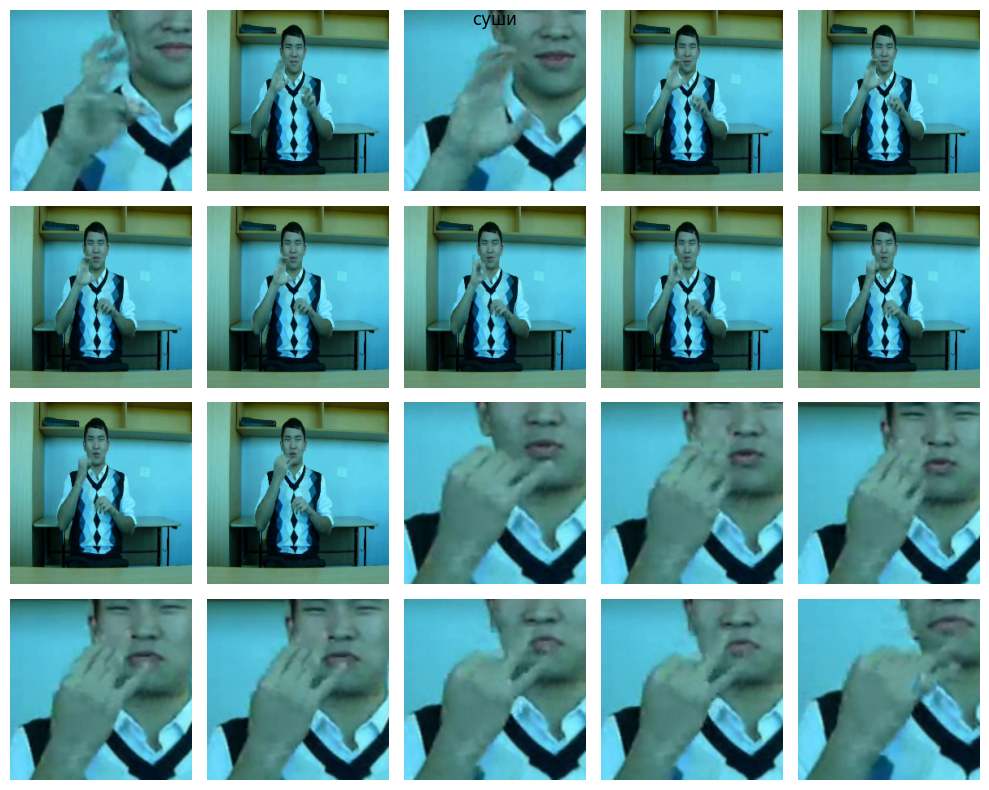

In [50]:
video_info = found_videos[1]
frames = preprocess_frames(video_info['path'])
length = len(frames)
display_frames(frames[length//2 - 10 : length//2 + 10], video_info['word'])

# Препроцесс для KP и RGB_KP

In [ ]:
# ЯЧЕЙКА 5.5: KP-препроцессор (эталонный подход HandReader)
# Для случаев если MODE = "KP" или "RGB_KP"

if "KP" in MODE:
    import mediapipe as mp
    import json
    import cv2
    import numpy as np

    INFERENCE_ARGS_FILE = os.path.join("data", "inference_args.json")

    # 1. Загрузка конфига нужных точек
    with open(INFERENCE_ARGS_FILE) as f:
        ALL_COLUMNS = json.load(f)['selected_columns']

    # 2. Фильтруем только hand + pose (как в эталонном даталоадере)
    FILTERED_COLUMNS = [
        col for col in ALL_COLUMNS
        if any(s in col for s in ['hand', 'pose'])
    ]

    # 3. Парсим названия точек
    def parse_kp_name(name):
        """x_left_hand_5 -> ('left_hand', 5)"""
        parts = name.split('_', 1)
        if len(parts) < 2:
            return None, None
        ltype = parts[1].rsplit('_', 1)[0]
        idx = int(parts[1].rsplit('_', 1)[1])
        return ltype, idx

    # 4. Определяем порядок точек (как в FILTERED_COLUMNS)
    LANDMARK_ORDER = []
    for col in FILTERED_COLUMNS:
        if col.startswith('x_'):
            ltype, idx = parse_kp_name(col)
            LANDMARK_ORDER.append((ltype, idx))

    NUM_KEYPOINTS = len(LANDMARK_ORDER)
    print(f"✅ KP настроены: {NUM_KEYPOINTS} точек")

    # 5. MediaPipe (один раз)
    mp_holistic = mp.solutions.holistic
    holistic = mp_holistic.Holistic(
        static_image_mode=True,
        model_complexity=2,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    # 6. Класс препроцессора
    class KPPreprocessor:
        def __init__(self):
            self.landmark_order = LANDMARK_ORDER
            self.num_keypoints = NUM_KEYPOINTS

        def extract_landmarks(self, frame_rgb):
            results = holistic.process(frame_rgb)

            left_hand = {}
            if results.left_hand_landmarks:
                for i, lm in enumerate(results.left_hand_landmarks.landmark):
                    left_hand[i] = (lm.x, lm.y, lm.z)

            right_hand = {}
            if results.right_hand_landmarks:
                for i, lm in enumerate(results.right_hand_landmarks.landmark):
                    right_hand[i] = (lm.x, lm.y, lm.z)

            pose = {}
            if results.pose_landmarks:
                for i, lm in enumerate(results.pose_landmarks.landmark):
                    pose[i] = (lm.x, lm.y, lm.z)

            landmarks = []
            for ltype, idx in self.landmark_order:
                if ltype == 'left_hand':
                    lm = left_hand.get(idx, (0.0, 0.0, 0.0))
                elif ltype == 'right_hand':
                    lm = right_hand.get(idx, (0.0, 0.0, 0.0))
                elif ltype == 'pose':
                    lm = pose.get(idx, (0.0, 0.0, 0.0))
                else:
                    lm = (0.0, 0.0, 0.0)
                landmarks.extend(lm)

            return np.array(landmarks, dtype=np.float32)

        def normalize(self, kp_sequence):
            x = kp_sequence.reshape(-1, self.num_keypoints, 3)
            mask = x != 0
            if mask.sum() > 0:
                mean = x[mask].mean()
                std = x[mask].std()
                if std > 0:
                    x = (x - mean) / std
            x = np.where(mask, x, 0.0)
            return x.reshape(-1, self.num_keypoints * 3)

        def process_video(self, video_path):
            cap = cv2.VideoCapture(video_path)
            all_landmarks = []

            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                landmarks = self.extract_landmarks(frame_rgb)
                all_landmarks.append(landmarks)

            cap.release()
            if not all_landmarks:
                return None, False

            kp_array = np.stack(all_landmarks)  # [T, 162]
            kp_norm = self.normalize(kp_array)  # [T, 162]

            # Решейпим в [1, T, 54, 3] — БАТЧ, ВРЕМЯ, ТОЧКИ, КАНАЛЫ
            kp_reshaped = kp_norm.reshape(-1, self.num_keypoints, 3)  # [T, 54, 3]
            kp_reshaped = np.expand_dims(kp_reshaped, 0)              # [1, T, 54, 3]

            return kp_reshaped, True

    # 7. Создаём экземпляр
    kp_preprocessor = KPPreprocessor()
    print("✅ KPPreprocessor готов к работе!")

else:
    kp_preprocessor = None
    print("ℹ️ KP не используется (MODE =", MODE, ")")

✅ KP настроены: 54 точек
✅ KPPreprocessor готов к работе!


# Извлечение эмбеддингов из видео.
Во всех кодах ниже эмбединги снова извлекаются (и нормируются), хотя могли бы использовать полученные тут


In [65]:
from tqdm import tqdm

print(f"🎯 Извлекаем {MODE} эмбеддинги для видео...\n")

all_embeddings = {}
video_data = []

for video_info in tqdm(found_videos[:5]):

    # RGB кадры (нужны для RGB и RGB_KP)
    if MODE in ["RGB", "RGB_KP"]:
        rgb_frames = preprocess_frames(video_info['path'])
        if len(rgb_frames) == 0:
            print(f"  ❌ {video_info['filename']}: нет RGB кадров")
            continue

    # KP точки (нужны для KP и RGB_KP)
    if MODE in ["KP", "RGB_KP"]:
        kp_frames, kp_success = kp_preprocessor.process_video(video_info['path'])
        if not kp_success:
            print(f"  ❌ {video_info['filename']}: нет KP точек")
            continue

    # Уравниваем длину для RGB_KP
    if MODE == "RGB_KP":
        min_len = min(len(rgb_frames), len(kp_frames))
        rgb_frames = rgb_frames[:min_len]
        kp_frames = kp_frames[:min_len]
        length = min_len
    elif MODE == "RGB":
        length = len(rgb_frames)
    elif MODE == "KP":
        length = len(kp_frames)

    # Тензоры
        # Тензоры
    if MODE == "RGB":
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        with torch.no_grad():
            emb = extractor(rgb_tensor, torch.tensor([length]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std
            emb_np = emb_norm.squeeze(0).cpu().numpy()

    elif MODE == "KP":
        kp_frames, ok = kp_preprocessor.process_video(video_info['path'])
        if not ok:
            print(f"  ❌ {video_info['filename']}: нет KP точек")
            continue

        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)
        length = kp_frames.shape[1]

        with torch.no_grad():
            emb = extractor(kp_tensor, torch.tensor([length]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std
            emb_np = emb_norm.squeeze(0).cpu().numpy()

    elif MODE == "RGB_KP":
        rgb_frames = preprocess_frames(video_info['path'])
        kp_frames, ok = kp_preprocessor.process_video(video_info['path'])

        if len(rgb_frames) == 0 or not ok:
            continue

        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)

        min_len = min(rgb_tensor.shape[0], kp_tensor.shape[1])
        rgb_tensor = rgb_tensor[:min_len]
        kp_tensor = kp_tensor[:, :min_len, :, :]

        with torch.no_grad():
            emb = extractor(rgb_tensor, kp_tensor, torch.tensor([min_len]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std
            emb_np = emb_norm.squeeze(0).cpu().numpy()

        length = min_len

    all_embeddings[video_info['filename']] = {
        'embeddings': emb_np,
        'word': video_info['word'],
        'path': video_info['path'],
        'num_frames': length
    }
    video_data.append({
        'filename': video_info['filename'],
        'word': video_info['word'],
        'emb_shape': emb_np.shape,
        'num_frames': length
    })
    print(f"  ✅ {video_info['filename']}: {length} кадров")

print(f"\n✅ Успешно обработано: {len(all_embeddings)} видео")

🎯 Извлекаем RGB_KP эмбеддинги для видео...



  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\boyko\miniconda3\envs\RGB_KP\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
 20%|██        | 1/5 [00:24<01:37, 24.28s/it]

  ✅ RSLN-n1-s1_01_раз.webm: 23 кадров


 40%|████      | 2/5 [00:53<01:21, 27.27s/it]

  ✅ RSLN-n2-s1_01_суши.webm: 31 кадров


...

  ✅ RSLN-n2-s1_02_был.webm: 26 кадров


 80%|████████  | 4/5 [01:45<00:26, 26.90s/it]

  ✅ RSLN-n2-s2_01_стюардесса.webm: 33 кадров


100%|██████████| 5/5 [02:05<00:00, 25.00s/it]

  ✅ RSLN-n4-s2_01_чай.webm: 21 кадров

✅ Успешно обработано: 5 видео


📊 Всего кадров из 5 видео: 134
   Размерность: (134, 1024)

🏷️ Распределение по 15 кластерам:
   Кластер 0: 8 кадров (6.0%)
   Кластер 1: 14 кадров (10.4%)
   Кластер 2: 20 кадров (14.9%)
   Кластер 3: 18 кадров (13.4%)
   Кластер 4: 5 кадров (3.7%)
   Кластер 5: 9 кадров (6.7%)
   Кластер 6: 6 кадров (4.5%)
   Кластер 7: 5 кадров (3.7%)
   Кластер 8: 5 кадров (3.7%)
   Кластер 9: 7 кадров (5.2%)
   Кластер 10: 5 кадров (3.7%)
   Кластер 11: 3 кадров (2.2%)
   Кластер 12: 9 кадров (6.7%)
   Кластер 13: 12 кадров (9.0%)
   Кластер 14: 8 кадров (6.0%)


C:\Users\boyko\AppData\Local\Temp\ipykernel_36752\4001605447.py:78: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\boyko\miniconda3\envs\RGB_KP\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


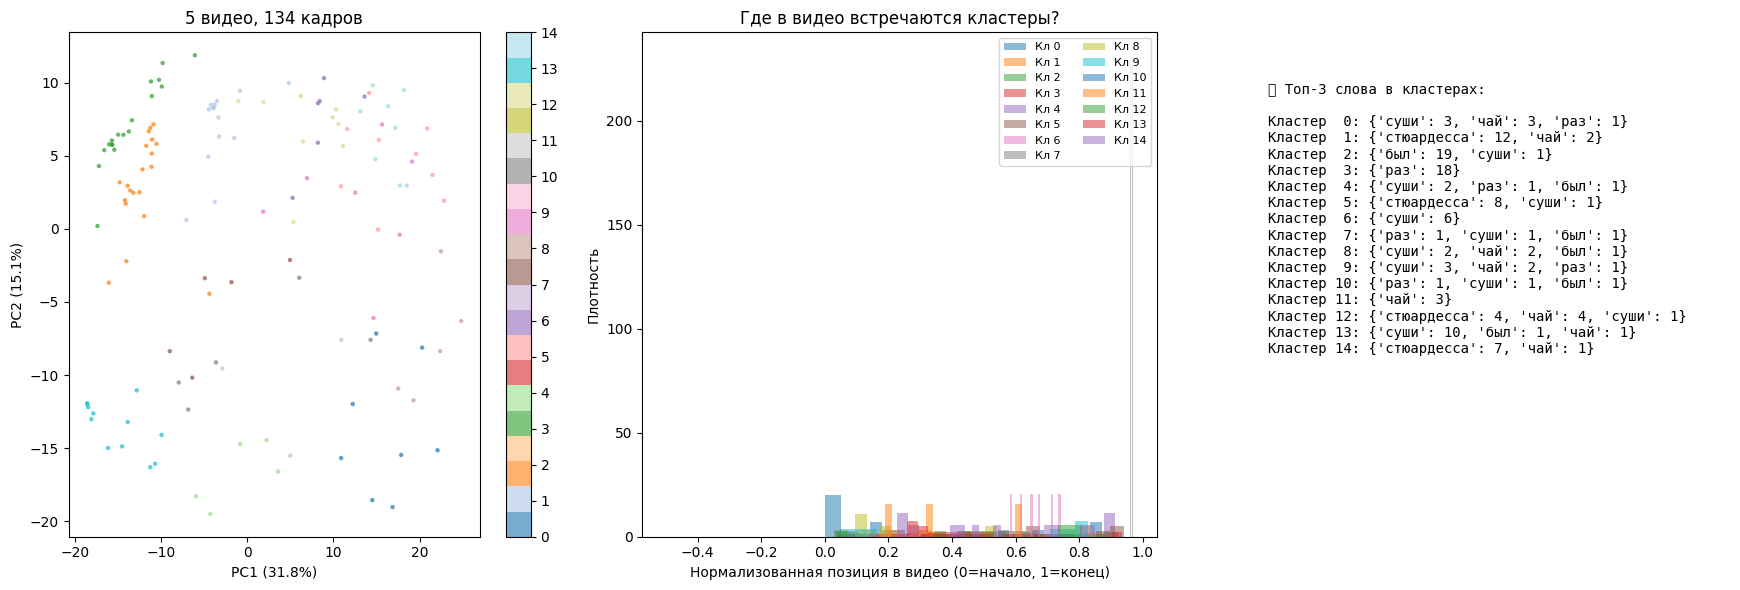


💡 Интерпретация:
   - ЛЕВЫЙ: кластеры в 2D
   - ЦЕНТР: если кластер встречается в начале/середине/конце видео — это дактилема перехода/удержания
   - ПРАВЫЙ: слова, попавшие в каждый кластер


In [66]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Собираем ВСЕ кадры из всех видео
all_frames = []
all_words = []
video_sources = []
frame_positions = []  # позиция кадра внутри видео (0..1)

for filename, data in all_embeddings.items():
    emb = data['embeddings']  # [T, 1024]
    word = data['word']
    T = data['num_frames']

    for i in range(T):
        all_frames.append(emb[i])
        all_words.append(word)
        video_sources.append(filename)
        frame_positions.append(i / T if T > 1 else 0)  # нормализованная позиция

X = np.stack(all_frames)
print(f"📊 Всего кадров из {len(all_embeddings)} видео: {X.shape[0]}")
print(f"   Размерность: {X.shape}")

# Кластеризация
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

print(f"\n🏷️ Распределение по {n_clusters} кластерам:")
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"   Кластер {cluster}: {count} кадров ({count/len(labels)*100:.1f}%)")

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1: PCA по кластерам
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab20', s=5, alpha=0.6)
axes[0].set_title(f'{len(all_embeddings)} видео, {X.shape[0]} кадров')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, ax=axes[0], ticks=range(n_clusters))

# 2: Распределение позиций кадров по кластерам
for cluster in range(n_clusters):
    mask = labels == cluster
    positions_in_cluster = np.array(frame_positions)[mask]
    if len(positions_in_cluster) > 0:
        axes[1].hist(positions_in_cluster, bins=20, alpha=0.5, label=f'Кл {cluster}', density=True)
axes[1].set_xlabel('Нормализованная позиция в видео (0=начало, 1=конец)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Где в видео встречаются кластеры?')
axes[1].legend(loc='upper right', fontsize=8, ncol=2)

# 3: Топ-слов в кластерах (текст)
axes[2].axis('off')
cluster_words = {i: [] for i in range(n_clusters)}
for label, word in zip(labels, all_words):
    cluster_words[label].append(word)

text_summary = "📋 Топ-3 слова в кластерах:\n\n"
for cluster in range(n_clusters):
    words = cluster_words[cluster]
    if words:
        top = Counter(words).most_common(3)
        text_summary += f"Кластер {cluster:2d}: {dict(top)}\n"
axes[2].text(0.1, 0.9, text_summary, transform=axes[2].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

print("\n💡 Интерпретация:")
print("   - ЛЕВЫЙ: кластеры в 2D")
print("   - ЦЕНТР: если кластер встречается в начале/середине/конце видео — это дактилема перехода/удержания")
print("   - ПРАВЫЙ: слова, попавшие в каждый кластер")

# Извлечение выходов модели

In [67]:
from demo_KP.utils import getRuTokens
from src.utils.ctc_decoder import Decoder

text_decoder = Decoder(getRuTokens())
print(f"✅ Декодер в текст загружен!")

✅ Декодер в текст загружен!


In [68]:
from tqdm import tqdm

def sigmoid(a: np.ndarray):
    return 1 / (1 + np.exp(-a))

print("🎯 Извлекаем выходы модели для видео (ВСЕ кадры, без семплирования)...\n")

video_data = []

# Берём последние 5 видео для теста
for video_info in tqdm(found_videos[-5:]):
    preprocessed_frames = preprocess_frames(video_info['path'])
    out, length, success = apply_model_full(
        preprocessed_frames,
        model
    )

    if success:
        video_data.append({
            'filename': video_info['filename'],
            'word': video_info['word'],
            'path': video_info['path'],
            'output': out,
            'output_proba': sigmoid(out),
            'out_shape': out.shape,
            'num_frames': length,
            'preprocessed': preprocessed_frames
        })
        # print(f"  ✅ {video_info['filename']}: {length} кадров")

print(f"\n✅ Успешно обработано: {len(video_data)} видео")

if video_data:
    print("\n📊 Результаты:")
    for v in video_data:
        print(f"   {v['filename']}: {v['word']} → {v['num_frames']} кадров, выход {v['out_shape']}")
        print(f"       Жадно: {''.join(text_decoder.greedy_decode(v['output_proba']))}")
        print(f"       Beam-поиск (beam_size=4): {''.join(text_decoder.beam_decode(v['output_proba'], 4))}")
    
    v = video_data[-1]
    display_frames(
        v['preprocessed'],
        f"{v['filename']}: {v['word']} → {v['num_frames']} кадров, выход {v['out_shape']}"
    )

🎯 Извлекаем выходы модели для видео (ВСЕ кадры, без семплирования)...



  0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\boyko\miniconda3\envs\RGB_KP\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
  0%|          | 0/5 [00:02<?, ?it/s]


TypeError: forward() missing 1 required positional argument: 'input_lenghts'

# Классификация (GRU и классификация после получения эмбедингов выше)

In [ ]:
from tqdm import tqdm
import torch
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. ПОДГОТОВКА ДЕКОДЕРА
# ============================================================
# Алфавит из конфига (35 символов: blank + 33 буквы + пробел)
ALPHABET = "_ абвгдежзийклмнопрстуфхцчшщъыьэюяё"

def ctc_collapse(indices, blank=0):
    """
    Схлопывает повторы и убирает blank (CTC Collapse).
    Пример: [_, _, н, н, _, о, о, _, й, й] -> [н, о, й]
    """
    result = []
    prev = blank
    for idx in indices:
        if idx != prev and idx != blank:
            result.append(idx)
        prev = idx
    return result

# ============================================================
# 2. ЦИКЛ ПО ВИДЕО: ИЗВЛЕЧЕНИЕ ЭМБЕДДИНГОВ + КЛАССИФИКАЦИЯ
# ============================================================
print("🎯 Классифицируем слова через GRU + Классификатор...\n")

recognition_results = []

# Берите столько видео, сколько нужно (например, 20)
for video_info in tqdm(found_videos[:20]):

    # --- ШАГ 1: ИЗВЛЕЧЕНИЕ ЭМБЕДДИНГОВ (КАК В ЯЧЕЙКЕ 7) ---
    if MODE == "RGB":
        rgb_frames = preprocess_frames(video_info['path'])
        if len(rgb_frames) == 0:
            continue
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        length = len(rgb_frames)
        with torch.no_grad():
            emb = extractor(rgb_tensor, torch.tensor([length]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std

    elif MODE == "KP":
        kp_frames, ok = kp_preprocessor.process_video(video_info['path'])
        if not ok:
            continue
        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)
        length = kp_frames.shape[1]
        with torch.no_grad():
            emb = extractor(kp_tensor, torch.tensor([length]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std

    elif MODE == "RGB_KP":
        rgb_frames = preprocess_frames(video_info['path'])
        kp_frames, ok = kp_preprocessor.process_video(video_info['path'])
        if len(rgb_frames) == 0 or not ok:
            continue
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)
        min_len = min(rgb_tensor.shape[0], kp_tensor.shape[1])
        rgb_tensor = rgb_tensor[:min_len]
        kp_tensor = kp_tensor[:, :min_len, :, :]
        length = min_len
        with torch.no_grad():
            emb = extractor(rgb_tensor, kp_tensor, torch.tensor([min_len]).to(DEVICE))
            # === НОРМАЛИЗАЦИЯ ===
            emb_mean = emb.mean(dim=-1, keepdim=True)
            emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
            emb_norm = (emb - emb_mean) / emb_std

        # --- ШАГ 2: КЛАССИФИКАЦИЯ (ДЕКОДЕР) ---
    with torch.no_grad():
        # ВАЖНО: emb имеет формат [1, T, 1024] — идеально для decoder_net (batch_first=True)
        logits = model.decoder_net(emb_norm)  # ← используем emb_norm
        logits = logits.squeeze(0)
        pred_indices = torch.argmax(logits, dim=-1).cpu().numpy()

    # --- ШАГ 3: CTC COLLAPSE -> СЛОВО ---
    collapsed = ctc_collapse(pred_indices, blank=0)
    recognized_word = ''.join([ALPHABET[i] for i in collapsed if i < len(ALPHABET)])

    # --- ШАГ 4: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ---
    recognition_results.append({
        'filename': video_info['filename'],
        'true_word': video_info['word'],
        'pred_word': recognized_word,
        'num_frames': length,
        'match': video_info['word'] == recognized_word
    })

# ============================================================
# 3. ВЫВОД РЕЗУЛЬТАТОВ
# ============================================================
print(f"\n📊 Результаты распознавания ({len(recognition_results)} видео):\n")

correct = 0
for r in recognition_results:
    status = "✅" if r['match'] else "❌"
    print(f"   {status} {r['filename']}: {r['true_word']} → {r['pred_word']} ({r['num_frames']} кадров)")
    if r['match']:
        correct += 1

print(f"\n🎯 Точность: {correct}/{len(recognition_results)} ({correct/len(recognition_results)*100:.1f}%)")

🎯 Классифицируем слова через GRU + Классификатор...



100%|██████████| 20/20 [02:19<00:00,  6.97s/it]


📊 Результаты распознавания (20 видео):

   ❌ RSLN-n1-s1_01_раз.webm: раз → па (23 кадров)
   ❌ RSLN-n2-s1_01_суши.webm: суши → шлица (31 кадров)
   ❌ RSLN-n2-s1_02_был.webm: был → ди (26 кадров)
   ❌ RSLN-n2-s2_01_стюардесса.webm: стюардесса → ца (33 кадров)
   ❌ RSLN-n4-s2_01_чай.webm: чай → гдуа (21 кадров)
   ❌ RSLN-n4-s2_02_чай.webm: чай → гд (17 кадров)
   ❌ RSLN-n4-s2_03_телеграмма.webm: телеграмма → цай (32 кадров)
   ❌ RSLN-n4-s2_04_регистрацию.webm: регистрацию → шей (43 кадров)
   ❌ RSLN-n4-s2_05_справочная.webm: справочная → эгэ (38 кадров)
   ❌ RSLN-n4-s2_06_рейс.webm: рейс → гча (21 кадров)
   ❌ RSLN-n4-s2_07_час.webm: час → йа (18 кадров)
   ❌ RSLN-n4-s2_08_час.webm: час → ц (21 кадров)
   ❌ RSLN-n4-s2_09_рейс.webm: рейс → са (27 кадров)
   ❌ RSLN-n4-s2_10_начальник.webm: начальник → гдйй (24 кадров)
   ❌ RSLN-n4-s2_11_регистрацию.webm: регистрацию → эцшй (39 кадров)
   ❌ RSLN-n4-s2_12_стюардесса.webm: стюардесса → да (34 кадров)
   ❌ RSLN-n4-s2_13_телеграмма.webm: телег

# Отладка по одному видео

🎯 Отлаживаем видео: RSLN-n2-s1_02_был.webm
   Истинное слово: был
   Путь: /content/drive/MyDrive/DactDetect/RSLN-n2-s1_02_был.webm

ЭТАП 1: ЗАГРУЗКА И ВИЗУАЛИЗАЦИЯ КАДРОВ
✅ Загружено RGB кадров: 26


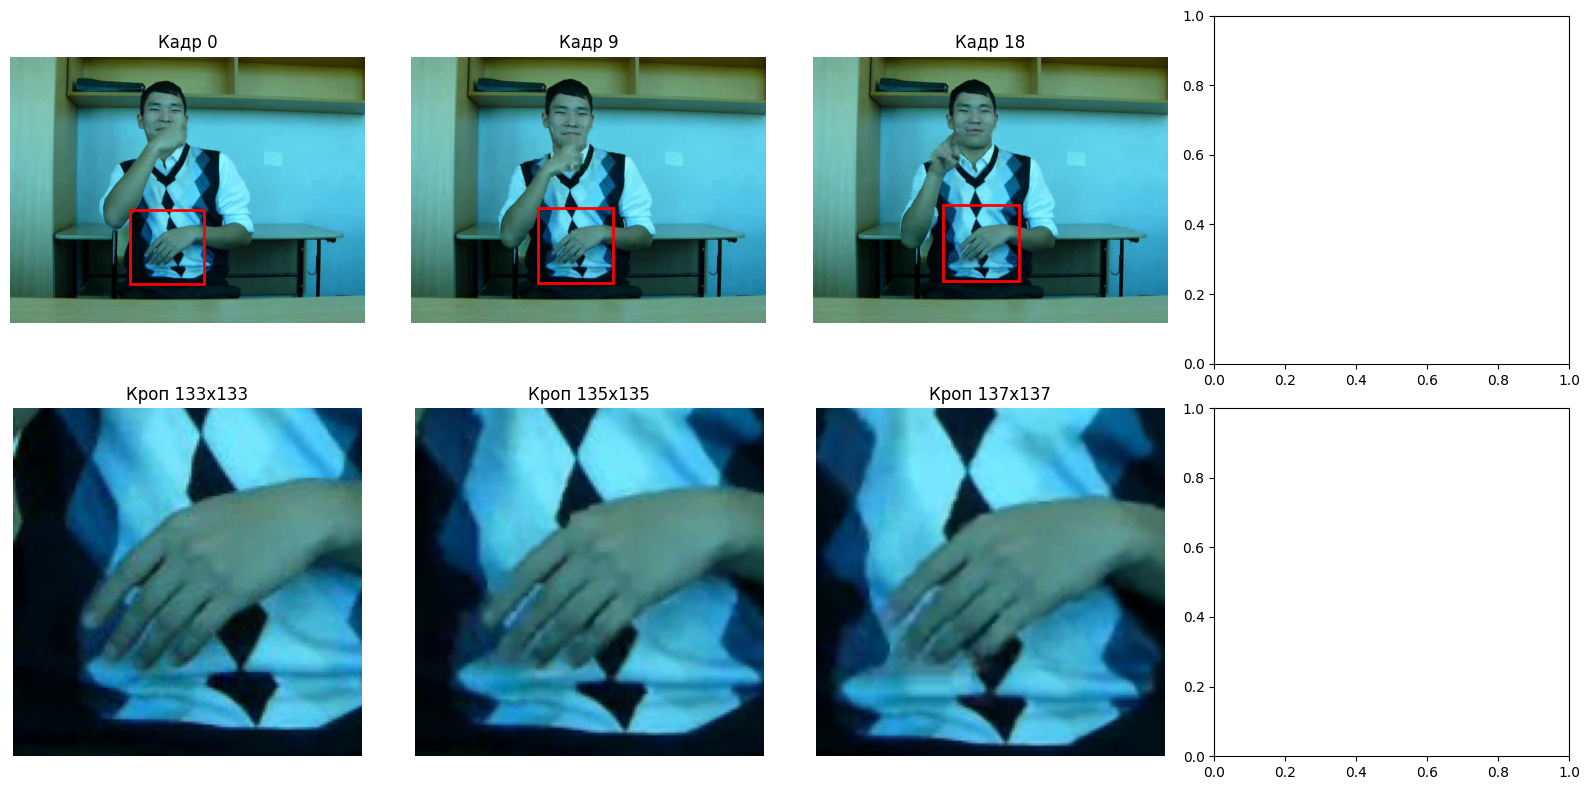


📊 Статистика кропов (25/27 кадров):
   Ширина: min=132, max=137, mean=134
   Высота: min=132, max=137, mean=134
   Aspect ratio (w/h): min=1.00, max=1.00, mean=1.00


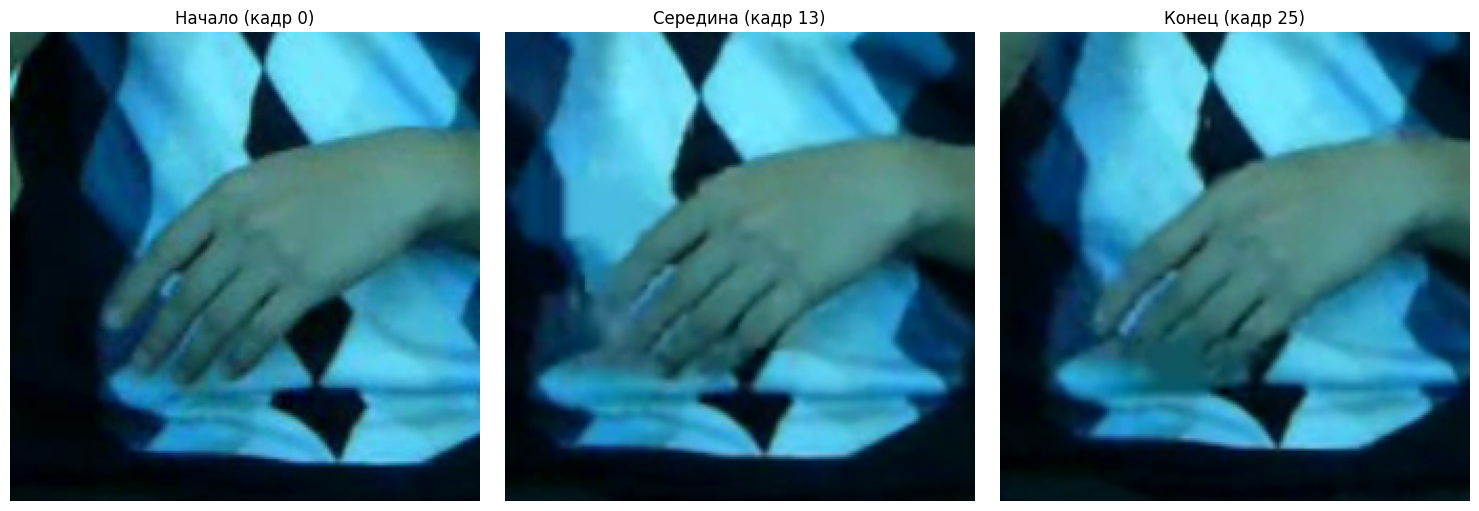


ЭТАП 2: ИЗВЛЕЧЕНИЕ ЭМБЕДДИНГОВ (MODE = RGB)
✅ RGB эмбеддинги: (26, 1024)
   Диапазон: [0.000, 5.213]
   Среднее: 0.200, Std: 0.327

ЭТАП 3: КЛАССИФИКАЦИЯ (GRU + Классификатор)
   До нормализации: mean=0.200, std=0.327
   После нормализации: mean=-0.000, std=1.000

ЭТАП 4: CTC ДЕКОДИРОВАНИЕ
Истинное слово:      'был'
Распознанное слово:  'д'
Совпадение:          ❌

🔍 Пошаговый CTC Collapse:
   До коллапса: ['д', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_']
   После коллапса: ['д']
   Собрано в слово: 'д'

ЭТАП 5: ПОБУКВЕННЫЙ АНАЛИЗ
Истинное слово по буквам: ['б', 'ы', 'л']
Распознано по буквам:     ['д']

📋 Выравнивание (примерное):
   ❌ Истина: 'б' <-> Модель: 'д'


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ============================================================
# ВЫБЕРИТЕ ВИДЕО ДЛЯ ОТЛАДКИ
# ============================================================
# Можно выбрать по индексу или по имени файла
TARGET_FILENAME = 'RSLN-n2-s1_02_был.webm'  # RSLN-n2-s1_01_суши.webm   RSLN-n2-s1_02_был.webm    RSLN-n2-s2_01_стюардесса.webm

# Находим видео в found_videos
target_video = None
for v in found_videos:
    if v['filename'] == TARGET_FILENAME:
        target_video = v
        break

if target_video is None:
    print(f"❌ Видео {TARGET_FILENAME} не найдено!")
    print("Доступные видео:")
    for v in found_videos[:5]:
        print(f"   {v['filename']}")
else:
    print(f"🎯 Отлаживаем видео: {target_video['filename']}")
    print(f"   Истинное слово: {target_video['word']}")
    print(f"   Путь: {target_video['path']}\n")

    # ============================================================
    # ЭТАП 1: ЗАГРУЗКА И ВИЗУАЛИЗАЦИЯ КАДРОВ (С РАСШИРЕННОЙ ОТЛАДКОЙ)
    # ============================================================
    print("=" * 60)
    print("ЭТАП 1: ЗАГРУЗКА И ВИЗУАЛИЗАЦИЯ КАДРОВ")
    print("=" * 60)

    if MODE in ["RGB", "RGB_KP"]:
        rgb_frames = preprocess_frames(target_video['path'], crop_hand=True)
        print(f"✅ Загружено RGB кадров: {len(rgb_frames)}")

        # --- 1. ВИЗУАЛИЗАЦИЯ КРОПА НА НЕСКОЛЬКИХ КАДРАХ ---
        cap = cv2.VideoCapture(target_video['path'])
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_to_check = [0, total_frames//3, 2*total_frames//3, total_frames-1]

        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for i, idx in enumerate(frames_to_check):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                cropped, bbox = crop_hand_region(frame_rgb, padding=30)

                # Исходный кадр с bbox
                ax1 = axes[0, i]
                ax1.imshow(frame_rgb)
                if bbox:
                    x_min, y_min, x_max, y_max = bbox
                    ax1.add_patch(plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                                 fill=False, edgecolor='red', linewidth=2))
                ax1.set_title(f"Кадр {idx}")
                ax1.axis('off')

                # Кропнутый кадр
                ax2 = axes[1, i]
                ax2.imshow(cropped)
                ax2.set_title(f"Кроп {cropped.shape[1]}x{cropped.shape[0]}")
                ax2.axis('off')
        plt.tight_layout()
        plt.show()

        # --- 2. СТАТИСТИКА ПО ВСЕМ КАДРАМ ---
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        crop_sizes = []
        crop_aspects = []
        hand_found = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            cropped, bbox = crop_hand_region(frame_rgb, padding=30)
            if bbox:
                hand_found += 1
                h, w = cropped.shape[:2]
                crop_sizes.append((w, h))
                crop_aspects.append(w / h if h > 0 else 0)

        cap.release()

        print(f"\n📊 Статистика кропов ({hand_found}/{total_frames} кадров):")
        if crop_sizes:
            sizes = np.array(crop_sizes)
            print(f"   Ширина: min={sizes[:,0].min()}, max={sizes[:,0].max()}, mean={sizes[:,0].mean():.0f}")
            print(f"   Высота: min={sizes[:,1].min()}, max={sizes[:,1].max()}, mean={sizes[:,1].mean():.0f}")
            print(f"   Aspect ratio (w/h): min={np.min(crop_aspects):.2f}, max={np.max(crop_aspects):.2f}, mean={np.mean(crop_aspects):.2f}")

        # --- 3. ВИЗУАЛИЗАЦИЯ ПРЕДОБРАБОТАННЫХ КАДРОВ ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, idx, title in zip(axes, [0, len(rgb_frames)//2, -1], ['Начало', 'Середина', 'Конец']):
            frame = rgb_frames[idx]
            frame = np.transpose(frame, (1, 2, 0))
            frame = frame * NORM_STD + NORM_MEAN
            frame = np.clip(frame, 0, 1)
            ax.imshow(frame)
            ax.set_title(f"{title} (кадр {idx if idx>=0 else len(rgb_frames)+idx})")
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    else:
        # Для KP загружаем оригинальные кадры (только для визуализации)
        cap = cv2.VideoCapture(target_video['path'])
        orig_frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            orig_frames.append(frame)
        cap.release()
        print(f"✅ Загружено оригинальных кадров: {len(orig_frames)}")
        # ... визуализация orig_frames ...

    # ============================================================
    # ЭТАП 2: ПРОГОН ЧЕРЕЗ ЭНКОДЕР (ПОЛУЧЕНИЕ ЭМБЕДДИНГОВ)
    # ============================================================
    print("\n" + "=" * 60)
    print(f"ЭТАП 2: ИЗВЛЕЧЕНИЕ ЭМБЕДДИНГОВ (MODE = {MODE})")
    print("=" * 60)

    if MODE == "RGB":
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        length = len(rgb_frames)
        with torch.no_grad():
            emb = extractor(rgb_tensor, torch.tensor([length]).to(DEVICE))
        emb_np = emb.squeeze(0).cpu().numpy()
        print(f"✅ RGB эмбеддинги: {emb_np.shape}")

    elif MODE == "KP":
        # Загружаем KP точки
        kp_frames, ok = kp_preprocessor.process_video(target_video['path'])
        if not ok:
            raise RuntimeError("Не удалось извлечь KP точки")
        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)
        length = kp_frames.shape[1]
        with torch.no_grad():
            emb = extractor(kp_tensor, torch.tensor([length]).to(DEVICE))
        emb_np = emb.squeeze(0).cpu().numpy()
        print(f"✅ KP эмбеддинги: {emb_np.shape}")

    elif MODE == "RGB_KP":
        # RGB
        rgb_tensor = torch.from_numpy(np.stack(rgb_frames)).to(DEVICE)
        # KP
        kp_frames, ok = kp_preprocessor.process_video(target_video['path'])
        if not ok:
            raise RuntimeError("Не удалось извлечь KP точки")
        kp_tensor = torch.from_numpy(kp_frames).to(DEVICE)
        # Уравниваем длину
        min_len = min(rgb_tensor.shape[0], kp_tensor.shape[1])
        rgb_tensor = rgb_tensor[:min_len]
        kp_tensor = kp_tensor[:, :min_len, :, :]
        length = min_len
        with torch.no_grad():
            emb = extractor(rgb_tensor, kp_tensor, torch.tensor([min_len]).to(DEVICE))
        emb_np = emb.squeeze(0).cpu().numpy()
        print(f"✅ RGB_KP эмбеддинги: {emb_np.shape}")

    print(f"   Диапазон: [{emb_np.min():.3f}, {emb_np.max():.3f}]")
    print(f"   Среднее: {emb_np.mean():.3f}, Std: {emb_np.std():.3f}")

    # ============================================================
    # ЭТАП 3: КЛАССИФИКАЦИЯ (GRU + LINEAR)
    # ============================================================
    print("\n" + "=" * 60)
    print("ЭТАП 3: КЛАССИФИКАЦИЯ (GRU + Классификатор)")
    print("=" * 60)

    # Универсальный доступ к декодеру
    if MODE == "KP":
        decoder = model.decoder
    else:
        decoder = model.decoder_net

    # === НОРМАЛИЗАЦИЯ ЭМБЕДДИНГОВ (ДОБАВИТЬ ЭТО!) ===
    emb_mean = emb.mean(dim=-1, keepdim=True)
    emb_std = emb.std(dim=-1, keepdim=True) + 1e-6
    emb_norm = (emb - emb_mean) / emb_std

    print(f"   До нормализации: mean={emb.mean():.3f}, std={emb.std():.3f}")
    print(f"   После нормализации: mean={emb_norm.mean():.3f}, std={emb_norm.std():.3f}")

    with torch.no_grad():
        logits = decoder(emb_norm)  # ← используем emb_norm вместо emb
        logits = logits.squeeze(0)
        probs = torch.softmax(logits, dim=-1)

    # ============================================================
    # ЭТАП 4: CTC COLLAPSE -> СЛОВО
    # ============================================================
    print("\n" + "=" * 60)
    print("ЭТАП 4: CTC ДЕКОДИРОВАНИЕ")
    print("=" * 60)

    def ctc_collapse(indices, blank=0):
        result = []
        prev = blank
        for idx in indices:
            if idx != prev and idx != blank:
                result.append(idx)
            prev = idx
        return result

    collapsed = ctc_collapse(pred_indices, blank=0)
    recognized_word = ''.join([ALPHABET[i] for i in collapsed if i < len(ALPHABET)])

    print(f"Истинное слово:      '{target_video['word']}'")
    print(f"Распознанное слово:  '{recognized_word}'")
    print(f"Совпадение:          {'✅' if target_video['word'] == recognized_word else '❌'}")

    # Пошаговый CTC Collapse
    print("\n🔍 Пошаговый CTC Collapse:")
    print(f"   До коллапса: {[ALPHABET[i] for i in pred_indices]}")
    print(f"   После коллапса: {[ALPHABET[i] for i in collapsed]}")
    print(f"   Собрано в слово: '{recognized_word}'")

    # ============================================================
    # ЭТАП 5: СРАВНЕНИЕ ПО БУКВАМ (если знаем позиции)
    # ============================================================
    print("\n" + "=" * 60)
    print("ЭТАП 5: ПОБУКВЕННЫЙ АНАЛИЗ")
    print("=" * 60)

    true_word = target_video['word']
    true_letters = list(true_word)

    print(f"Истинное слово по буквам: {true_letters}")
    print(f"Распознано по буквам:     {[ALPHABET[i] for i in collapsed]}")

    # Выравнивание (упрощённое)
    print("\n📋 Выравнивание (примерное):")
    true_idx = 0
    pred_idx = 0
    while true_idx < len(true_letters) and pred_idx < len(collapsed):
        t_let = true_letters[true_idx]
        p_let = ALPHABET[collapsed[pred_idx]]
        match = "✅" if t_let == p_let else "❌"
        print(f"   {match} Истина: '{t_let}' <-> Модель: '{p_let}'")
        true_idx += 1
        pred_idx += 1

# визуализация кластеризации + классификации по N видео

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import Counter

# ============================================================
# ВЫБЕРИТЕ КОЛИЧЕСТВО ВИДЕО ДЛЯ ВИЗУАЛИЗАЦИИ
# ============================================================
N_VIDEOS = 5  # сколько видео показать

# ============================================================
# СБОР ДАННЫХ
# ============================================================
all_frames = []
all_words = []
all_pred_words = []
all_frame_positions = []
video_boundaries = [0]

for video_info in found_videos[:N_VIDEOS]:
    data = all_embeddings.get(video_info['filename'])
    if data is None:
        continue

    emb = data['embeddings']  # [T, D]
    word = data['word']
    T = data['num_frames']

    # Находим предсказанное слово из результатов классификации
    pred_word = None
    for r in recognition_results:
        if r['filename'] == video_info['filename']:
            pred_word = r['pred_word']
            break

    for i in range(T):
        all_frames.append(emb[i])
        all_words.append(word)
        all_pred_words.append(pred_word or '?')
        all_frame_positions.append(i / T if T > 1 else 0)

    video_boundaries.append(video_boundaries[-1] + T)

X = np.stack(all_frames)
print(f"📊 Всего кадров: {X.shape[0]}, размерность: {X.shape[1]}")

# ============================================================
# КЛАСТЕРИЗАЦИЯ
# ============================================================
n_clusters = min(12, X.shape[0] // 10 + 3)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X)

# ============================================================
# PCA ДЛЯ 2D ВИЗУАЛИЗАЦИИ
# ============================================================
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# ============================================================
# СООТВЕТСТВИЕ КЛАСТЕРОВ БУКВАМ (упрощённо)
# ============================================================
cluster_to_letter = {}
for cluster in range(n_clusters):
    mask = cluster_labels == cluster
    words_in_cluster = [all_words[i] for i, m in enumerate(mask) if m]
    if words_in_cluster:
        # Самая частая буква в этом кластере (упрощённо — первая буква слов)
        first_letters = [w[0] if w else '_' for w in words_in_cluster]
        most_common = Counter(first_letters).most_common(1)[0][0]
        cluster_to_letter[cluster] = most_common

# ============================================================
# ГИГАНТСКАЯ ВИЗУАЛИЗАЦИЯ (3 строки × 2 столбца на видео)
# ============================================================
fig = plt.figure(figsize=(20, 5 * N_VIDEOS))

for v_idx in range(N_VIDEOS):
    start_idx = video_boundaries[v_idx]
    end_idx = video_boundaries[v_idx + 1]

    video_name = list(all_embeddings.keys())[v_idx]
    true_word = all_words[start_idx]
    pred_word = all_pred_words[start_idx]

    # --- ГРАФИК 1: PCA проекция (все видео + выделено текущее) ---
    ax1 = fig.add_subplot(N_VIDEOS, 3, v_idx * 3 + 1)

    # Все видео (фон)
    ax1.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', s=2, alpha=0.3)

    # Текущее видео (цвета по кластерам)
    video_clusters = cluster_labels[start_idx:end_idx]
    video_points = X_2d[start_idx:end_idx]
    scatter = ax1.scatter(video_points[:, 0], video_points[:, 1],
                          c=video_clusters, cmap='tab10', s=15, alpha=0.8)

    ax1.set_title(f'PCA: {true_word} → {pred_word}')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

    # --- ГРАФИК 2: Кластеры во времени ---
    ax2 = fig.add_subplot(N_VIDEOS, 3, v_idx * 3 + 2)

    T = end_idx - start_idx
    time_axis = np.linspace(0, 1, T)
    ax2.scatter(time_axis, video_clusters, c=video_clusters, cmap='tab10', s=30, alpha=0.8)
    ax2.plot(time_axis, video_clusters, 'k-', alpha=0.3)

    # Подписываем буквы на кластерах
    for cluster in range(n_clusters):
        if cluster in video_clusters:
            letter = cluster_to_letter.get(cluster, '?')
            ax2.text(1.01, cluster, letter, transform=ax2.get_yaxis_transform(),
                     fontsize=10, fontweight='bold')

    ax2.set_xlabel('Нормализованное время')
    ax2.set_ylabel('Кластер')
    ax2.set_title(f'Кластеры во времени: {true_word}')
    ax2.set_yticks(range(n_clusters))
    ax2.grid(alpha=0.3)

    # --- ГРАФИК 3: Сравнение букв ---
    ax3 = fig.add_subplot(N_VIDEOS, 3, v_idx * 3 + 3)
    ax3.axis('off')

    # Распределение кластеров
    cluster_counts = Counter(video_clusters)
    text = f"📊 {true_word} → {pred_word}\n\n"
    text += "Кластеры:\n"
    for cluster, count in sorted(cluster_counts.items()):
        letter = cluster_to_letter.get(cluster, '?')
        pct = count / T * 100
        text += f"  Кл{cluster} ('{letter}'): {count} кадров ({pct:.0f}%)\n"

    ax3.text(0.1, 0.9, text, transform=ax3.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

# ============================================================
# ИТОГОВАЯ СТАТИСТИКА
# ============================================================
print("\n" + "=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 60)

correct = sum(1 for r in recognition_results[:N_VIDEOS] if r['match'])
print(f"🎯 Точность на {N_VIDEOS} видео: {correct}/{N_VIDEOS} ({correct/N_VIDEOS*100:.1f}%)")

# Связь кластеров с точностью
print("\n📋 Соответствие кластеров буквам (упрощённо):")
for cluster, letter in sorted(cluster_to_letter.items()):
    count = sum(1 for l in cluster_labels if l == cluster)
    print(f"   Кластер {cluster:2d} → '{letter}' ({count} кадров)")

NameError: name 'found_videos' is not defined